# **1. Chargement des librairies**

In [ ]:
! pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 15.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import kruskal
import pingouin as pg
from sklearn.preprocessing import LabelEncoder

# **2. Chargement de la table**

In [ ]:
# Récupérer les données du dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# **3. Informations de la table *df***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# **4. Préparation de la table**

1. On va classifier les employés par tranches d'âges, puis encoder ces classes d'âges.
2. On va encoder toutes les variables catégorielles textes en variables catégoriques numériques

In [ ]:
# Définir les tranches d'âge
bins = [18, 24, 34, 44, 54, 65]
age_class = ['18-24', '25-34', '35-44', '45-54', '55-65']

# Créer une nouvelle colonne pour les tranches d'âge
df['AgeClass'] = pd.cut(df['Age'], bins=bins, labels=age_class, right=True, include_lowest=True)

# Convertir la colonne "AgeClass" en numérique
# (18-24 = 0, 25-34 = 1, 35-44 = 2, 45-54 = 3, 55-65 = 4)
mapping_AgeClass = {'18-24' : 0, '25-34' : 1, '35-44' : 2, '45-54' : 3,'55-65' : 4}
df['AgeClass'] = df['AgeClass'].map(mapping_AgeClass)

In [ ]:
# Convertir la colonne 'Attrition' en numérique (Yes = 1, No = 0)
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == "Yes" else 0)

# Convertir la colonne "BusinessTravel" en numérique (Non-Travel = 0, Travel_Rarely = 1, Travel_Frequently = 2)
mapping_BTravel = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(mapping_BTravel)

# Convertir la colonne "Department" en numérique (HR = 0, R&D= 1, Sales = 2)
mapping_dept = {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
df['Department'] = df['Department'].map(mapping_dept)

# Convertir la colonne "EducationField" en numérique
# (Other = 0, Human Resources = 1, Life Sciences = 2, Medical = 3, Technical Degree = 4, Marketing = 5)
mapping_EducField = {'Other' : 0, 'Human Resources' : 1, 'Life Sciences' : 2, 'Medical' : 3, 'Technical Degree' : 4, 'Marketing' : 5}
df['EducationField'] = df['EducationField'].map(mapping_EducField)

# Convertir la colonne 'Gender' en numérique (Female = 0, Male = 1)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Convertir la colonne "JobRole" en numérique
# (Manager = 0, Human Resources = 1, Manufacturing Director = 2, Research Director = 3,
# Research Scientist = 4, Laboratory Technician = 5, Healthcare Representative = 6,
# Sales Executive = 7, Sales Representative = 8)
mapping_JobRole = {'Manager' : 0, 'Human Resources' : 1, 'Manufacturing Director' : 2, 'Research Director' : 3,
                   'Research Scientist' : 4, 'Laboratory Technician' : 5, 'Healthcare Representative' : 6,
                   'Sales Executive' : 7, 'Sales Representative' : 8}
df['JobRole'] = df['JobRole'].map(mapping_JobRole)

# Convertir la colonne 'MaritalStatus' (Divorced = 0, Married = 1, Single = 2)
mapping_MariStat = {'Divorced': 0, 'Married': 1, 'Single': 2}
df['MaritalStatus'] = df['MaritalStatus'].map(mapping_MariStat)

# Convertir la colonne 'OverTime' en numérique (Yes = 1, No = 0)
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

# **5.Tests statistiques de distribution**

**Création d'un score global de satisfaction au travail**

Pour créer ce score global, nous allons combiner les différents indicateurs de satisfaction :
- JobSatisfaction,
- EnvironmentSatisfaction,
- JobInvolvement,
- PerformanceRating,
- RelationshipSatisfaction,
- WorkLifeBalance

Il s'agira de la colonne "GlobalSatisfaction" dans *df*





In [ ]:
# Création du score global de satisfaction
df['GlobalSatisfaction'] = df[['JobSatisfaction', 'EnvironmentSatisfaction',
                                   'JobInvolvement', 'PerformanceRating',
                                   'RelationshipSatisfaction','WorkLifeBalance']].mean(axis=1)
df['GlobalSatisfaction'].describe()

,GlobalSatisfaction
count,1470.000000
mean,2.801247
std,0.359862
min,1.500000
25%,2.500000
50%,2.833333
75%,3.000000
max,3.833333


## **5.1. Visualisation des distributions**

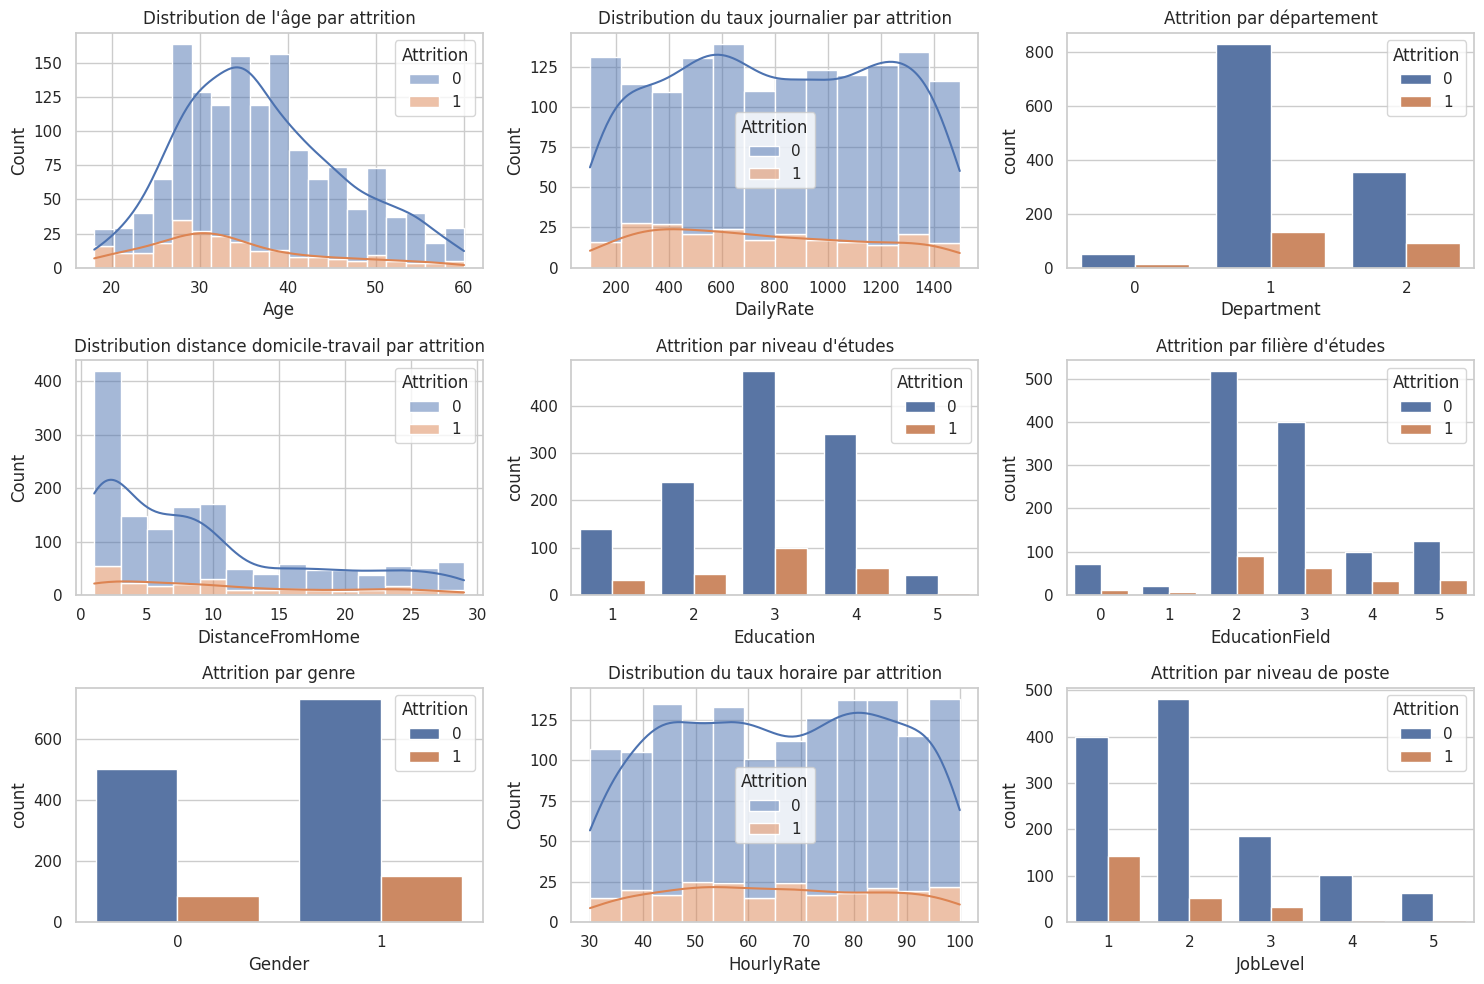

In [ ]:
# Configurer le style des graphiques
sns.set(style="whitegrid")

# Taille de la figure
plt.figure(figsize=(15, 10))

# Création de sous-graphiques pour chaque variable en fonction de l'attrition

# Âge
plt.subplot(3,3,1)
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution de l\'âge par attrition')

# Taux journalier
plt.subplot(3,3,2)
sns.histplot(data=df, x='DailyRate', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du taux journalier par attrition')

# Département
plt.subplot(3,3,3)
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition par département')

# Distance domicle-travail
plt.subplot(3,3,4)
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution distance domicile-travail par attrition')

# Niveau d'études
plt.subplot(3,3,5)
sns.countplot(data=df, x='Education', hue='Attrition')
plt.title('Attrition par niveau d\'études')

# Filière d'études
plt.subplot(3,3,6)
sns.countplot(data=df, x='EducationField', hue='Attrition')
plt.title('Attrition par filière d\'études')

# Genre
plt.subplot(3,3,7)
sns.countplot(data=df, x='Gender', hue='Attrition')
plt.title('Attrition par genre')

# Taux horaire
plt.subplot(3,3,8)
sns.histplot(data=df, x='HourlyRate', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du taux horaire par attrition')

# Niveau de poste
plt.subplot(3,3,9)
sns.countplot(data=df, x='JobLevel', hue='Attrition')
plt.title('Attrition par niveau de poste')

plt.tight_layout()
plt.show()

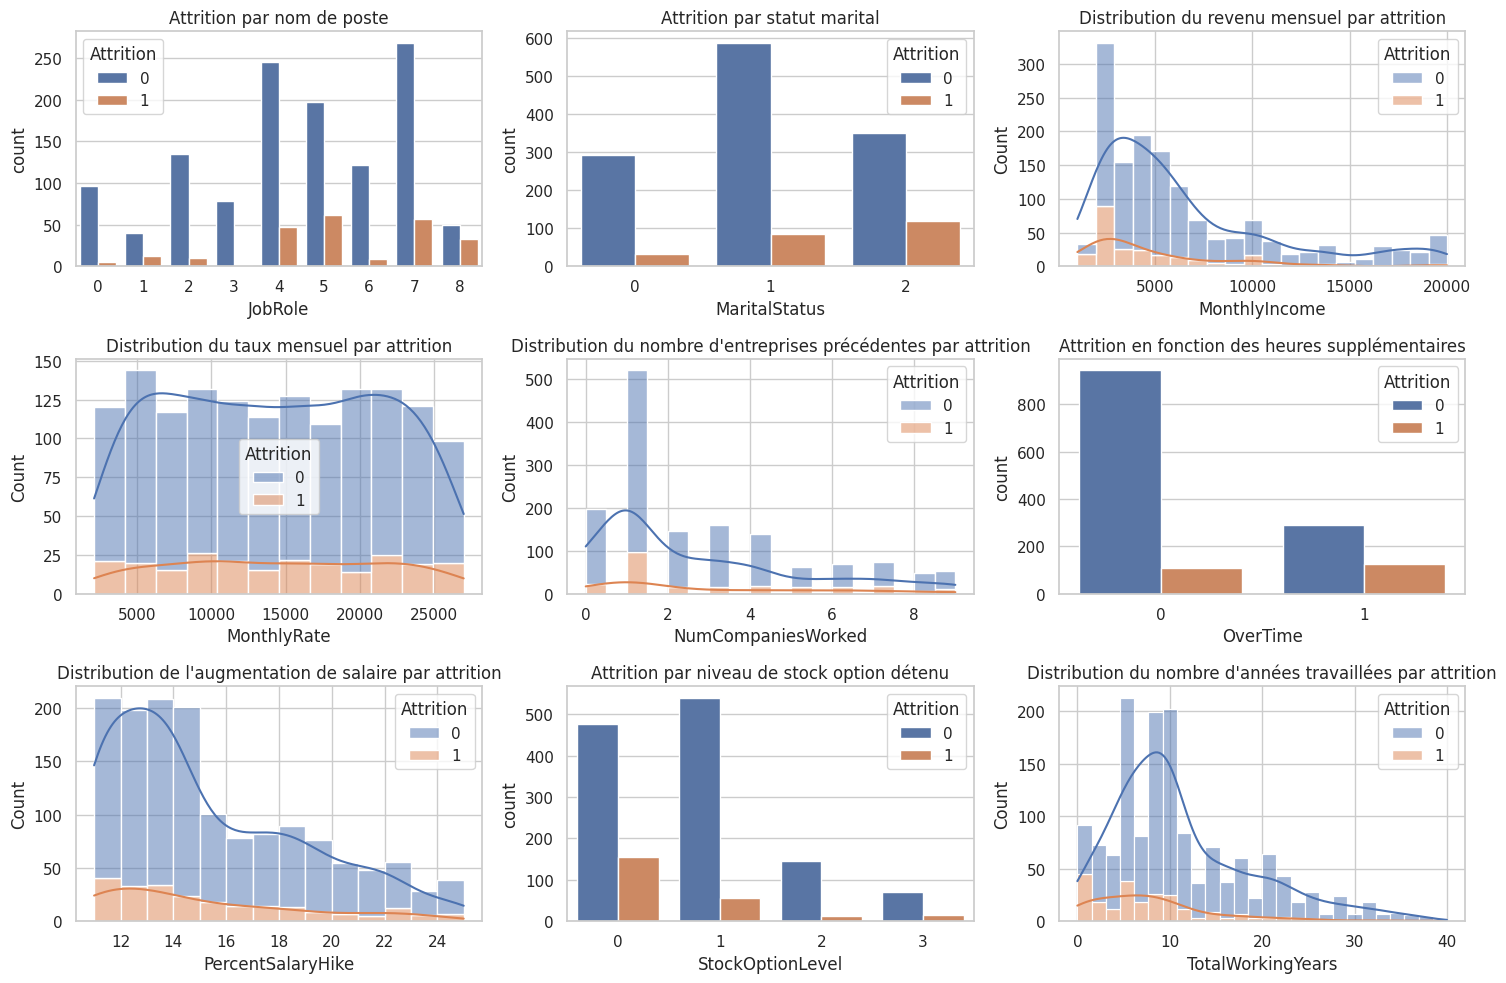

In [ ]:
# Configurer le style des graphiques
sns.set(style="whitegrid")

# Taille de la figure
plt.figure(figsize=(15, 10))

# Création de sous-graphiques pour chaque variable en fonction de l'attrition

# Nom de poste
plt.subplot(3,3,1)
sns.countplot(data=df, x='JobRole', hue='Attrition')
plt.title('Attrition par nom de poste')

# Statut marital
plt.subplot(3,3,2)
sns.countplot(data=df, x='MaritalStatus', hue='Attrition')
plt.title('Attrition par statut marital')

# Revenu mensuel
plt.subplot(3,3,3)
sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du revenu mensuel par attrition')

# Taux mensuel
plt.subplot(3,3,4)
sns.histplot(data=df, x='MonthlyRate', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du taux mensuel par attrition')

# Nombre d'entreprises précédentes
plt.subplot(3,3,5)
sns.histplot(data=df, x='NumCompaniesWorked', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du nombre d\'entreprises précédentes par attrition')

# Heures supplémentaires
plt.subplot(3,3,6)
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition en fonction des heures supplémentaires')

# Pourcentage d'augmentation de salaire
plt.subplot(3,3,7)
sns.histplot(data=df, x='PercentSalaryHike', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution de l\'augmentation de salaire par attrition')

# Niveau de Stock Option
plt.subplot(3,3,8)
sns.countplot(data=df, x='StockOptionLevel', hue='Attrition')
plt.title('Attrition par niveau de stock option détenu')

# Nombre d'années travaillées
plt.subplot(3,3,9)
sns.histplot(data=df, x='TotalWorkingYears', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du nombre d\'années travaillées par attrition')

plt.tight_layout()
plt.show()

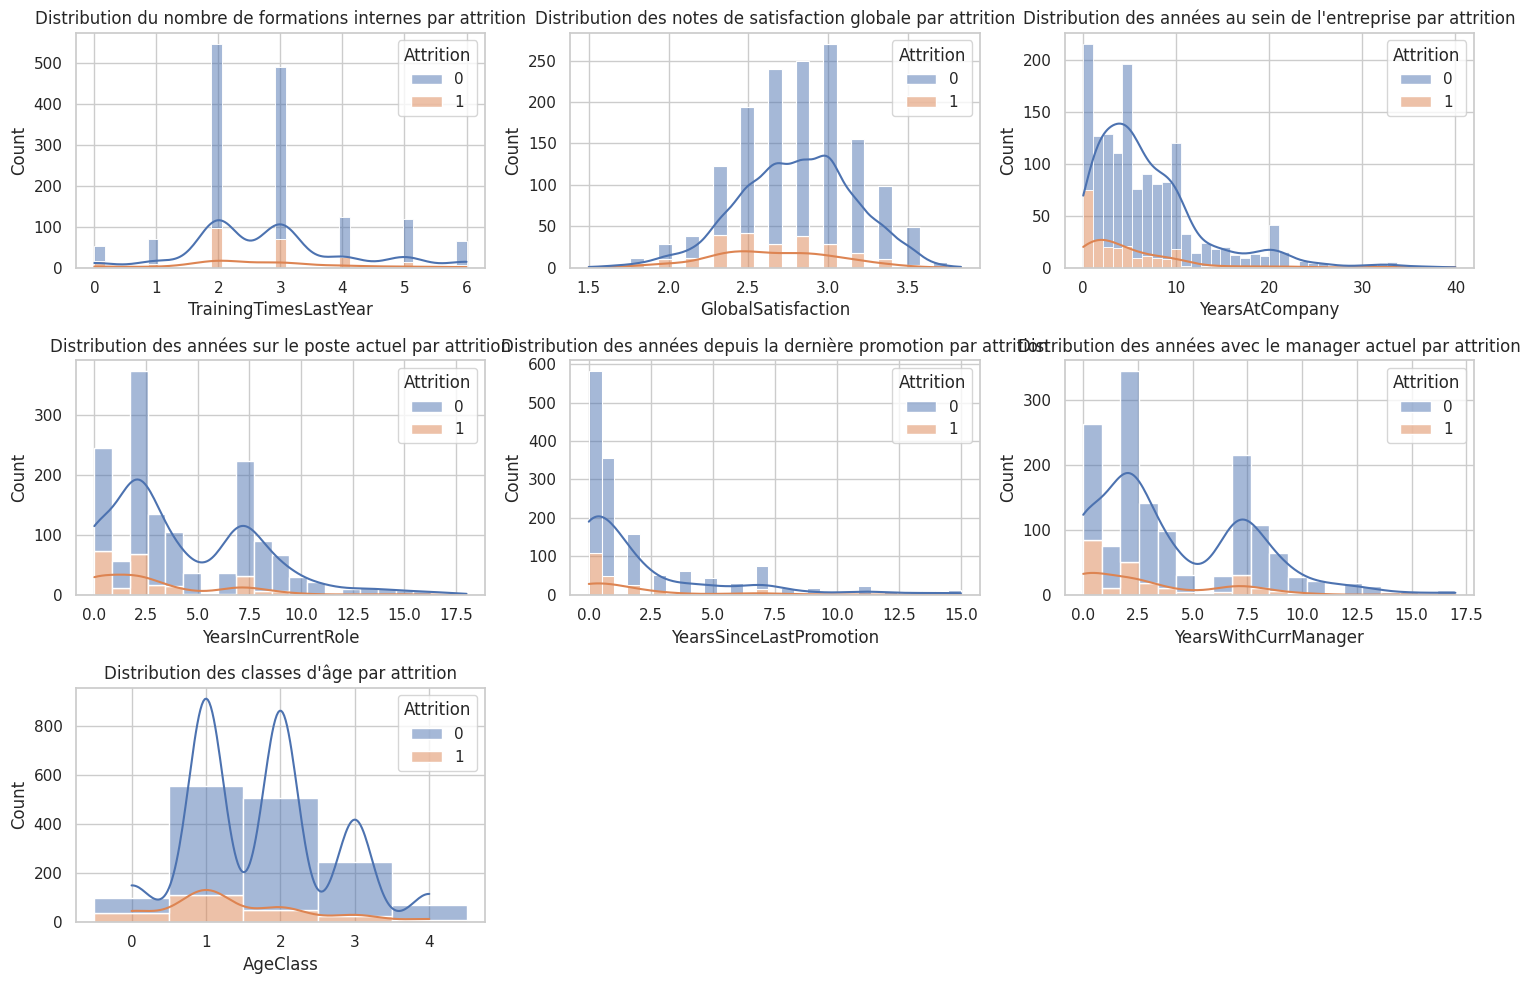

In [ ]:
# Configurer le style des graphiques
sns.set(style="whitegrid")

# Taille de la figure
plt.figure(figsize=(15, 10))

# Création de sous-graphiques pour chaque variable en fonction de l'attrition

# Nombre de formations internes au cours de l'année précédente
plt.subplot(3,3,1)
sns.histplot(data=df, x='TrainingTimesLastYear', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution du nombre de formations internes par attrition')

# Satisfaction globale (moyenne de 6 indicateurs)
plt.subplot(3,3,2)
sns.histplot(data=df, x='GlobalSatisfaction', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des notes de satisfaction globale par attrition')

# Années au sein de l'entreprise
plt.subplot(3,3,3)
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des années au sein de l\'entreprise par attrition')

# Années passées sur le poste actuel
plt.subplot(3,3,4)
sns.histplot(data=df, x='YearsInCurrentRole', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des années sur le poste actuel par attrition')

# Années passées depuis la dernière promotion
plt.subplot(3,3,5)
sns.histplot(data=df, x='YearsSinceLastPromotion', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des années depuis la dernière promotion par attrition')

# Années passées avec le manager actuel
plt.subplot(3,3,6)
sns.histplot(data=df, x='YearsWithCurrManager', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des années avec le manager actuel par attrition')

# Classes d'âge
plt.subplot(3,3,7)
sns.histplot(data=df, x='AgeClass', hue='Attrition', multiple='stack', kde=True)
plt.title('Distribution des classes d\'âge par attrition')


plt.tight_layout()
plt.show()

## **5.2. Séparation des employés restés VS partis**

In [ ]:
df_stay = df[ df["Attrition"] == 0 ]
df_gone = df[ df["Attrition"] == 1 ]

## **5.3. Test de normalité**
Avec le test de Shapiro-Wilk, nous avons comparé chacune des 25 variables pour chacun des 2 groupes (GONE et STAY) ci-dessous. D'après les résultats obtenus, seules les distributions de **2 variables suivent une loi normale : *Age* et *MaritalStatus*** (visuellement).

**L'âge a une influence sur le départ du salarié**

In [ ]:
# [STAY] Age
data = df_stay['Age']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.978, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Age
data = df_gone['Age']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.946, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Les classes d'âge ont une influence sur le départ du salarié**

In [ ]:
# [STAY] Classes d'âge
data = df_stay['AgeClass']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.888, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Age
data = df_gone['AgeClass']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.863, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Les voyages professionnels ont une influence sur le départ du salarié**

In [ ]:
# [STAY] BusinessTravel
data = df_stay['BusinessTravel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.705, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] BusinessTravel
data = df_gone['BusinessTravel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.704, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le service a une influence sur le départ du salarié**

In [ ]:
# [STAY] Service
data = df_stay['Department']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.687, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Service
data = df_gone['Department']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.731, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le taux horaire a une influence sur le départ du salarié**

In [ ]:
# [STAY] HourlyRate
data = df_stay['HourlyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.954, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] HourlyRate
data = df_gone['HourlyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.956, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le taux journalier a une influence sur le départ du salarié**

In [ ]:
# [STAY] DailyRate
data = df_stay['DailyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.954, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] DailyRate
data = df_gone['DailyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.950, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le taux mensuel a une influence sur le départ du salarié**

In [ ]:
# [STAY] MonthlyRate
data = df_stay['MonthlyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.954, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] MonthlyRate
data = df_gone['MonthlyRate']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.953, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le revenu mensuel a une influence sur le départ du salarié**

In [ ]:
# [STAY] MonthlyIncome
data = df_stay['MonthlyIncome']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.834, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] MonthlyIncome
data = df_gone['MonthlyIncome']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.780, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La distance domicile-travail a une influence sur le départ du salarié**

In [ ]:
# [STAY] Distance domicile-travail
data = df_stay['DistanceFromHome']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.853, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Distance domicile-travail
data = df_gone['DistanceFromHome']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.896, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le niveau d'étude a une influence sur le départ du salarié**

In [ ]:
# [STAY] Niveau d'étude
data = df_stay['Education']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.897, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Niveau d'étude
data = df_gone['Education']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.886, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La filière d'étude a une influence sur le départ du salarié**

In [ ]:
# [STAY] Filière d'étude
data = df_stay['EducationField']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.875, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Filière d'étude
data = df_gone['EducationField']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.898, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le genre a une influence sur le départ du salarié**

In [ ]:
# [STAY] Genre
data = df_stay['Gender']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.624, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Genre
data = df_gone['Gender']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.610, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le niveau de poste a une influence sur le départ du salarié**

In [ ]:
# [STAY] Niveau de poste
data = df_stay['JobLevel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.835, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Niveau de poste
data = df_gone['JobLevel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.701, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le type de poste occupé a une influence sur le départ du salarié**

In [ ]:
# [STAY] Type de poste
data = df_stay['JobRole']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.930, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Type de poste
data = df_gone['JobRole']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.907, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le statut marital a une influence sur le départ du salarié**

In [ ]:
# [STAY] Statut marital
data = df_stay['MaritalStatus']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.809, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Statut marital
data = df_gone['MaritalStatus']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.754, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**L'expérience pro (nb d'entreprises préc.) a une influence sur le départ du salarié**

In [ ]:
# [STAY] Expérience (nb d'entreprises préc.)
data = df_stay['NumCompaniesWorked']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.850, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Expérience (nb d'entreprises préc.)
data = df_gone['NumCompaniesWorked']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.835, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Les heures supplémentaires ont une influence sur le départ du salarié**

In [ ]:
# [STAY] Heures supplémentaires
data = df_stay['OverTime']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.525, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Heures supplémentaires
data = df_gone['OverTime']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.635, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**L'augmentation de salaire a une influence sur le départ du salarié**

In [ ]:
# [STAY] Niveau d'augmentation de salaire
data = df_stay['PercentSalaryHike']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.903, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Niveau d'augmentation de salaire
data = df_gone['PercentSalaryHike']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.886, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Le niveau de stock option détenu a une influence sur le départ du salarié**

In [ ]:
# [STAY] Niveau de stock option détenu
data = df_stay['StockOptionLevel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.804, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Niveau de stock option détenu
data = df_gone['StockOptionLevel']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.647, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**L'expérience pro (en années) a une influence sur le départ du salarié**

In [ ]:
# [STAY] Expérience pro (en années)
data = df_stay['TotalWorkingYears']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.910, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Expérience pro (en années)
data = df_gone['TotalWorkingYears']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.850, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**Les formations internes ont une influence sur le départ du salarié**

In [ ]:
# [STAY] Formations internes
data = df_stay['TrainingTimesLastYear']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.893, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Formations internes
data = df_gone['TrainingTimesLastYear']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.901, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La satisfaction globale a une influence sur le départ du salarié**

In [ ]:
# [STAY] Satisfaction globale au travail
data = df_stay['GlobalSatisfaction']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.977, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [GONE] Satisfaction globale au travail
data = df_gone['GlobalSatisfaction']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.976, p=0.001
Les données ne suivent pas une distribution normale (rejeter H0)


**L'ancienneté au sein de l'entreprise a une influence sur le départ du salarié**

In [ ]:
# [GONE] Ancienneté au sein de l'entreprise
data = df_gone['YearsAtCompany']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.722, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [STAY] Ancienneté au sein de l'entreprise
data = df_stay['YearsAtCompany']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.852, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La durée passée sur le poste actuel a une influence sur le départ du salarié**

In [ ]:
# [GONE] Durée passée sur le poste actuel
data = df_gone['YearsInCurrentRole']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.818, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [STAY] Durée passée sur le poste actuel
data = df_stay['YearsInCurrentRole']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.907, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La durée depuis la dernière promotion a une influence sur le départ du salarié**

In [ ]:
# [GONE] Durée depuis la dernière promotion
data = df_gone['YearsSinceLastPromotion']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.660, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [STAY] Durée depuis la dernière promotion
data = df_stay['YearsSinceLastPromotion']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.711, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


**La durée passée avec le manager actuel a une influence sur le départ du salarié**

In [ ]:
# [GONE] Durée passée avec le manager actuel
data = df_gone['YearsWithCurrManager']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.830, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


In [ ]:
# [STAY] Durée passée avec le manager actuel
data = df_stay['YearsWithCurrManager']
stat, p_value = shapiro(data)
print('Statistics=%.3f, p=%.3f' % (stat, p_value))

# Interprétation
alpha = 0.05
if p_value > alpha:
    print('Les données suivent une distribution normale (ne pas rejeter H0)')
else:
    print('Les données ne suivent pas une distribution normale (rejeter H0)')

Statistics=0.905, p=0.000
Les données ne suivent pas une distribution normale (rejeter H0)


## **5.4. Homogénéité des variances**
Avec le test de Levene, les résultats obtenus sont les suivants :

> **Variances homogènes** (14/25 variables) : *Age*, *BusinessTravel*, *HourlyRate*, *DailyRate*, *MonthlyRate*, *Education*, *EducationField*, *Gender*, *NumCompaniesWorked*, *PercentSalaryHike*, *TotalWorkingYears*, *TrainingTimesLastYear*, *YearsAtCompany*, *YearsSinceLastPromotion*

> **Variances non homogènes** (11/25 variables) : *Department*, *MonthlyIncome*, *DistanceFromHome*, *JobLevel*, *JobRole*, *MaritalStatus*, *OverTime*, *StockOptionLevel*, *GlobalSatisfaction*, *YearsInCurrentRole*, *YearsWithCurrManager*

**Variance de la variable : âge**

In [ ]:
# Variable : Age
homogeneity = pg.homoscedasticity(df, dv= "Age", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.487849  0.484999       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : classes d'âge**

In [ ]:
# Variable : Classes d'âge
homogeneity = pg.homoscedasticity(df, dv= "AgeClass", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.000405  0.983938       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : voyages pro**

In [ ]:
# Variable : Voyages professionnels
homogeneity = pg.homoscedasticity(df, dv= "BusinessTravel", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

              W      pval  equal_var
levene  3.61133  0.057583       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : service**

In [ ]:
# Variable : Service
homogeneity = pg.homoscedasticity(df, dv= "Department", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

                W      pval  equal_var
levene  10.757791  0.001063      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : taux horaire**

In [ ]:
# Variable : Taux horaire
homogeneity = pg.homoscedasticity(df, dv= "HourlyRate", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.451051  0.501942       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : taux journalier**

In [ ]:
# Variable : Taux journalier
homogeneity = pg.homoscedasticity(df, dv= "DailyRate", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.137038  0.711297       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : taux mensuel**

In [ ]:
# Variable : Taux mensuel
homogeneity = pg.homoscedasticity(df, dv= "MonthlyRate", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.031507  0.859137       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : revenu mensuel**

In [ ]:
# Variable : Revenu mensuel
homogeneity = pg.homoscedasticity(df, dv= "MonthlyIncome", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

                W      pval  equal_var
levene  14.899587  0.000118      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : distance domicile-travail**

In [ ]:
# Variable : Distance domicile-travail
homogeneity = pg.homoscedasticity(df, dv= "DistanceFromHome", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  3.913526  0.048086      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : niveau d'étude**

In [ ]:
# Variable : Niveau d'étude
homogeneity = pg.homoscedasticity(df, dv= "Education", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.368134  0.544117       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : filière d'étude**

In [ ]:
# Variable : Filière d'études
homogeneity = pg.homoscedasticity(df, dv= "EducationField", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  2.867303  0.090608       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : genre**

In [ ]:
# Variable : Genre
homogeneity = pg.homoscedasticity(df, dv= "Gender", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  1.274587  0.259092       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : niveau de poste**

In [ ]:
# Variable : Niveau de poste
homogeneity = pg.homoscedasticity(df, dv= "JobLevel", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  7.285488  0.007031      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : poste occupé**

In [ ]:
# Variable : Poste occupé
homogeneity = pg.homoscedasticity(df, dv= "JobRole", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  6.514261  0.010802      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : statut marital**

In [ ]:
# Variable : Statut marital
homogeneity = pg.homoscedasticity(df, dv= "MaritalStatus", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  8.327992  0.003961      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : l'expérience pro (nb d'entreprises préc.)**

In [ ]:
# Variable : Expérience pro (nb d'entreprises préc.)
homogeneity = pg.homoscedasticity(df, dv= "NumCompaniesWorked", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  3.301201  0.069433       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : heures supplémentaires**

In [ ]:
# Variable : Heures supplémentaires
homogeneity = pg.homoscedasticity(df, dv= "OverTime", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W          pval  equal_var
levene  54.97206  2.057130e-13      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : augmentation de salaire**

In [ ]:
# Variable : Augmentation de salaire
homogeneity = pg.homoscedasticity(df, dv= "PercentSalaryHike", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.344869  0.557123       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : niveau de stock option détenu**

In [ ]:
# Variable : Stock option détenu
homogeneity = pg.homoscedasticity(df, dv= "StockOptionLevel", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  4.035887  0.044725      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : expérience pro (en années)**

In [ ]:
# Variable : Expérience pro en années
homogeneity = pg.homoscedasticity(df, dv= "TotalWorkingYears", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  3.062385  0.080333       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : formations en interne**

In [ ]:
# Variable : Formation en interne
homogeneity = pg.homoscedasticity(df, dv= "TrainingTimesLastYear", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  0.000491  0.982317       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : satisfaction globale au travail**

In [ ]:
# Variable : Satisfaction globale au travail
homogeneity = pg.homoscedasticity(df, dv= "GlobalSatisfaction", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  5.794728  0.016197      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : ancienneté dans l'entreprise**

In [ ]:
# Variable : Ancienneté
homogeneity = pg.homoscedasticity(df, dv= "YearsAtCompany", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  2.753398  0.097262       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : durée sur le poste actuel**

In [ ]:
# Variable : Durée sur le poste actuel
homogeneity = pg.homoscedasticity(df, dv= "YearsInCurrentRole", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

                W      pval  equal_var
levene  16.023011  0.000066      False
Les variances entre les deux groupes ne sont pas homogènes


**Variance de la variable : durée depuis la dernière promotion**

In [ ]:
# Variable : Durée depuis la dernière promotion
homogeneity = pg.homoscedasticity(df, dv= "YearsSinceLastPromotion", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W     pval  equal_var
levene  0.393775  0.53042       True
Les variances entre les deux groupes sont homogènes


**Variance de la variable : durée passée avec le manager actuel**

In [ ]:
# Variable : Durée passée avec le manager actuel
homogeneity = pg.homoscedasticity(df, dv= "YearsWithCurrManager", group= "Attrition")
print(homogeneity)

# Interprétation
if homogeneity.iloc[0,2] == True:
    print('Les variances entre les deux groupes sont homogènes')
else:
    print('Les variances entre les deux groupes ne sont pas homogènes')

               W      pval  equal_var
levene  9.661766  0.001918      False
Les variances entre les deux groupes ne sont pas homogènes


# **6. Test d'indépendance des observations**

D'après les résultats obtenus, **les distributions de toutes nos variables (sauf *Age* et *MaritalStatus*) ne suivent pas une loi normale**, et **14 variables  sur 25 ont des variances homogènes entre les deux groupes** basés sur l'attrition.

On va étudier au sein de chaque service, l'indépendance des observations (par variable catégorique) entre chaque groupe d'attrition :

- **avec le test de Khi²** : *BusinessTravel*, *Education*, *EducationField*, *Gender*, *JobLevel*, *JobRole*, *MaritalStatus*, *OverTime*, *StockOptionLevel*

## **6.1. Tests Khi²**

In [ ]:
# 3 datasets filtrés sur les services

hr_df = df[df['Department'] == 0]
rd_df = df[df['Department'] == 1]
sales_df = df[df['Department'] == 2]

### **6.1.1. Service Sales**
> **Variables impactantes pour le service Sales** :
- *AgeClass*
- *BusinessTravel*
- *JobLevel*
- *JobRole*
- *MaritalStatus*
- *OverTime*
- *StockOptionLevel*

pval < 0,05 signifie que les résultats ont peu de chance d'être dus au hasard, donc il y a de fortes chances que notre variable X a une corrélation avec notre résultat y

power = score / 100 : notre khi² est bon ou non

Si on a peu de fréquence, utiliser neyman

In [ ]:
chi2_sales_AgeClass = pg.chi2_independence(sales_df, x='AgeClass', y='Attrition')
chi2_sales_AgeClass

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 AgeClass                        
 0           21.430493   5.569507
 1          146.044843  37.955157
 2          109.533632  28.466368
 3           62.704036  16.295964
 4           14.286996   3.713004,
 Attrition    0   1
 AgeClass          
 0           13  14
 1          145  39
 2          118  20
 3           62  17
 4           16   2,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  20.320276  4.0  0.000432  0.213451  0.966614
 1        cressie-read  0.666667  19.132180  4.0  0.000740  0.207117  0.956005
 2      log-likelihood  0.000000  17.486572  4.0  0.001554  0.198009  0.936224
 3       freeman-tukey -0.500000  16.758514  4.0  0.002153  0.193843  0.925161
 4  mod-log-likelihood -1.000000  16.375895  4.0  0.002554  0.191617  0.918689
 5              neyman -2.000000  16.458514  4.0  0.002462  0.192100  0.920127)

In [ ]:
# puis vous appliquez le test en changeant le x, sans toucher à l'attrition car on veut voir ce qui peut la provoquer
chi2_sales_travel = pg.chi2_independence(sales_df, x='BusinessTravel', y='Attrition')
chi2_sales_travel

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition                0          1
 BusinessTravel                       
 0                37.304933   9.695067
 1               250.022422  64.977578
 2                66.672646  17.327354,
 Attrition         0   1
 BusinessTravel         
 0                43   4
 1               255  60
 2                56  28,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  12.977375  2.0  0.001521  0.170579  0.907503
 1        cressie-read  0.666667  12.900113  2.0  0.001580  0.170071  0.905758
 2      log-likelihood  0.000000  12.963496  2.0  0.001531  0.170488  0.907191
 3       freeman-tukey -0.500000  13.222928  2.0  0.001345  0.172185  0.912859
 4  mod-log-likelihood -1.000000  13.695877  2.0  0.001062  0.175238  0.922398
 5              neyman -2.000000  15.474895  2.0  0.000436  0.186272  0.950404)

In [ ]:
chi2_sales_Educ = pg.chi2_independence(sales_df, x='Education', y='Attrition')
chi2_sales_Educ

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 Education                       
 1           39.686099  10.313901
 2           69.053812  17.946188
 3          131.757848  34.242152
 4          101.596413  26.403587
 5           11.905830   3.094170,
 Attrition    0   1
 Education         
 1           39  11
 2           69  18
 3          127  39
 4          105  23
 5           14   1,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  3.229082  4.0  0.520247  0.085089  0.261389
 1        cressie-read  0.666667  3.362401  4.0  0.499106  0.086828  0.271474
 2      log-likelihood  0.000000  3.712606  4.0  0.446295  0.091237  0.298116
 3       freeman-tukey -0.500000  4.075422  4.0  0.395895  0.095591  0.325842
 4  mod-log-likelihood -1.000000  4.561297  4.0  0.335341  0.101129  0.362940
 5              neyman -2.000000  6.126551  4.0  0.189895  0.117204  0.479201)

In [ ]:
chi2_sales_EducField = pg.chi2_independence(sales_df, x='EducationField', y='Attrition')
chi2_sales_EducField

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition                0          1
 EducationField                       
 0                11.905830   3.094170
 2               119.058296  30.941704
 3                69.847534  18.152466
 4                26.986547   7.013453
 5               126.201794  32.798206,
 Attrition         0   1
 EducationField         
 0                11   4
 2               121  29
 3                74  14
 4                24  10
 5               124  35,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  3.472886  4.0  0.482013  0.088243  0.279859
 1        cressie-read  0.666667  3.441231  4.0  0.486870  0.087839  0.277454
 2      log-likelihood  0.000000  3.392005  4.0  0.494488  0.087209  0.273718
 3       freeman-tukey -0.500000  3.366761  4.0  0.498424  0.086884  0.271804
 4  mod-log-likelihood -1.000000  3.351021  4.0  0.500889  0.086680  0.270612
 5              neyman -2.000000  3.346744  4.0  0.501560  0.086625  0.270288)

In [ ]:
chi2_sales_Gender = pg.chi2_independence(sales_df, x='Gender', y='Attrition')
chi2_sales_Gender

(Attrition           0          1
 Gender                          
 0          150.013453  38.986547
 1          203.986547  53.013453,
 Attrition      0     1
 Gender                
 0          150.5  38.5
 1          203.5  53.5,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  0.013276  1.0  0.908269  0.005456  0.051522
 1        cressie-read  0.666667  0.013280  1.0  0.908257  0.005457  0.051523
 2      log-likelihood  0.000000  0.013287  1.0  0.908231  0.005458  0.051523
 3       freeman-tukey -0.500000  0.013293  1.0  0.908212  0.005459  0.051524
 4  mod-log-likelihood -1.000000  0.013298  1.0  0.908193  0.005460  0.051525
 5              neyman -2.000000  0.013310  1.0  0.908153  0.005463  0.051526)

In [ ]:
chi2_sales_JobLevel = pg.chi2_independence(sales_df, x='JobLevel', y='Attrition')
chi2_sales_JobLevel

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 JobLevel                        
 1           60.322870  15.677130
 2          190.493274  49.506726
 3           65.878924  17.121076
 4           26.986547   7.013453
 5           10.318386   2.681614,
 Attrition    0   1
 JobLevel          
 1           44  32
 2          203  37
 3           66  17
 4           30   4
 5           11   2,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  27.243336  4.0  0.000018  0.247151  0.994026
 1        cressie-read  0.666667  26.058025  4.0  0.000031  0.241715  0.991880
 2      log-likelihood  0.000000  24.263802  4.0  0.000071  0.233245  0.987196
 3       freeman-tukey -0.500000  23.339410  4.0  0.000108  0.228759  0.983883
 4  mod-log-likelihood -1.000000  22.716200  4.0  0.000144  0.225684  0.981213
 5              neyman -2.000000  22.228086  4.0  0.000181  0.223246  0.978838)

In [ ]:
chi2_sales_JobRole = pg.chi2_independence(sales_df, x='JobRole', y='Attrition')
chi2_sales_JobRole

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 JobRole                         
 0           29.367713   7.632287
 7          258.753363  67.246637
 8           65.878924  17.121076,
 Attrition    0   1
 JobRole           
 0           35   2
 7          269  57
 8           50  33,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  25.757870  2.0  2.551229e-06  0.240319   
 1        cressie-read  0.666667  25.166377  2.0  3.429182e-06  0.237543   
 2      log-likelihood  0.000000  24.701953  2.0  4.325528e-06  0.235341   
 3       freeman-tukey -0.500000  25.051322  2.0  3.632240e-06  0.237000   
 4  mod-log-likelihood -1.000000  26.142240  2.0  2.105158e-06  0.242105   
 5              neyman -2.000000  31.683410  2.0  1.318363e-07  0.266531   
 
       power  
 0  0.997183  
 1  0.996643  
 2  0.996150  
 3  0.996526  
 4  0.997488  
 5  0.999540  )

In [ ]:
chi2_sales_MariStat = pg.chi2_independence(sales_df, x='MaritalStatus', y='Attrition')
chi2_sales_MariStat

(Attrition               0          1
 MaritalStatus                       
 0               69.053812  17.946188
 1              163.506726  42.493274
 2              121.439462  31.560538,
 Attrition        0   1
 MaritalStatus         
 0               77  10
 1              177  29
 2              100  53,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  28.180061  2.0  7.599368e-07  0.251364   
 1        cressie-read  0.666667  27.705506  2.0  9.634424e-07  0.249239   
 2      log-likelihood  0.000000  27.089075  2.0  1.311240e-06  0.246450   
 3       freeman-tukey -0.500000  26.901958  2.0  1.439839e-06  0.245598   
 4  mod-log-likelihood -1.000000  26.942592  2.0  1.410882e-06  0.245783   
 5              neyman -2.000000  27.710229  2.0  9.611699e-07  0.249260   
 
       power  
 0  0.998641  
 1  0.998430  
 2  0.998109  
 3  0.997999  
 4  0.998024  
 5  0.998433  )

In [ ]:
chi2_sales_OverTime = pg.chi2_independence(sales_df, x='OverTime', y='Attrition')
chi2_sales_OverTime

(Attrition           0          1
 OverTime                        
 0          252.403587  65.596413
 1          101.596413  26.403587,
 Attrition      0     1
 OverTime              
 0          273.5  44.5
 1           80.5  47.5,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  29.784727  1.0  4.827805e-08  0.258422   
 1        cressie-read  0.666667  28.948878  1.0  7.431385e-08  0.254770   
 2      log-likelihood  0.000000  27.688020  1.0  1.425428e-07  0.249160   
 3       freeman-tukey -0.500000  27.058608  1.0  1.973794e-07  0.246312   
 4  mod-log-likelihood -1.000000  26.668362  1.0  2.415443e-07  0.244529   
 5              neyman -2.000000  26.526922  1.0  2.598909e-07  0.243880   
 
       power  
 0  0.999765  
 1  0.999687  
 2  0.999520  
 3  0.999406  
 4  0.999323  
 5  0.999290  )

In [ ]:
chi2_sales_StockOpt = pg.chi2_independence(sales_df, x='StockOptionLevel', y='Attrition')
chi2_sales_StockOpt

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition                  0          1
 StockOptionLevel                       
 0                 156.363229  40.636771
 1                 138.901345  36.098655
 2                  41.273543  10.726457
 3                  17.461883   4.538117,
 Attrition           0   1
 StockOptionLevel         
 0                 133  64
 1                 159  16
 2                  46   6
 3                  16   6,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  34.238790  3.0  1.764049e-07  0.277071   
 1        cressie-read  0.666667  34.498472  3.0  1.554799e-07  0.278120   
 2      log-likelihood  0.000000  35.584971  3.0  9.164786e-08  0.282466   
 3       freeman-tukey -0.500000  36.966507  3.0  4.677073e-08  0.287897   
 4  mod-log-likelihood -1.000000  38.928671  3.0  1.797117e-08  0.295439   
 5              neyman -2.000000  45.119294  3.0  8.728007e-10  0.318063   
 
       power  
 0  0.999518  
 1  0.999553  
 2  0.99967

### **6.1.2. Service HR**

> **Variables impactantes pour le service HR** :
- *AgeClass*

In [ ]:
chi2_hr_AgeClass = pg.chi2_independence(hr_df, x='AgeClass', y='Attrition')
chi2_hr_AgeClass

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7991: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


(Attrition          0         1
 AgeClass                      
 0           2.428571  0.571429
 1          17.809524  4.190476
 2          20.238095  4.761905
 3           7.285714  1.714286
 4           3.238095  0.761905,
 Attrition   0  1
 AgeClass        
 0           1  2
 1          14  8
 2          23  2
 3           9  0
 4           4  0,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  13.727487  4.0  0.008218  0.466794  0.858852
 1        cressie-read  0.666667  13.564563  4.0  0.008823  0.464016  0.854181
 2      log-likelihood  0.000000  14.752250  4.0  0.005244  0.483904  0.885419
 3       freeman-tukey -0.500000        NaN  4.0       NaN       NaN       NaN
 4  mod-log-likelihood -1.000000        inf  4.0  0.000000       inf       NaN
 5              neyman -2.000000        NaN  4.0       NaN       NaN       NaN)

In [ ]:
# puis vous appliquez le test en changeant le x, sans toucher à l'attrition car on veut voir ce qui peut la provoquer
chi2_hr_travel = pg.chi2_independence(hr_df, x='BusinessTravel', y='Attrition')
chi2_hr_travel

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7991: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


(Attrition               0         1
 BusinessTravel                     
 0                4.857143  1.142857
 1               37.238095  8.761905
 2                8.904762  2.095238,
 Attrition        0  1
 BusinessTravel       
 0                6  0
 1               38  8
 2                7  4,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  3.632644  2.0  0.162623  0.240127  0.381432
 1        cressie-read  0.666667  3.728710  2.0  0.154996  0.243281  0.390389
 2      log-likelihood  0.000000  4.423007  2.0  0.109536  0.264965  0.453600
 3       freeman-tukey -0.500000       NaN  2.0       NaN       NaN       NaN
 4  mod-log-likelihood -1.000000       inf  2.0  0.000000       inf       NaN
 5              neyman -2.000000       NaN  2.0       NaN       NaN       NaN)

In [ ]:
chi2_hr_Educ = pg.chi2_independence(hr_df, x='Education', y='Attrition')
chi2_hr_Educ

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition          0         1
 Education                     
 1           4.047619  0.952381
 2          10.523810  2.476190
 3          21.857143  5.142857
 4          12.142857  2.857143
 5           2.428571  0.571429,
 Attrition   0  1
 Education       
 1           4  1
 2          10  3
 3          23  4
 4          12  3
 5           2  1,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  0.859427  4.0  0.930308  0.116798  0.096963
 1        cressie-read  0.666667  0.843354  4.0  0.932543  0.115700  0.096002
 2      log-likelihood  0.000000  0.818410  4.0  0.935963  0.113976  0.094517
 3       freeman-tukey -0.500000  0.805237  4.0  0.937745  0.113055  0.093736
 4  mod-log-likelihood -1.000000  0.796218  4.0  0.938954  0.112421  0.093202
 5              neyman -2.000000  0.789063  4.0  0.939908  0.111914  0.092779)

In [ ]:
chi2_hr_EducField = pg.chi2_independence(hr_df, x='EducationField', y='Attrition')
chi2_hr_EducField

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7991: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


(Attrition               0         1
 EducationField                     
 0                2.428571  0.571429
 1               21.857143  5.142857
 2               12.952381  3.047619
 3               10.523810  2.476190
 4                3.238095  0.761905,
 Attrition        0  1
 EducationField       
 0                3  0
 1               20  7
 2               15  1
 3               11  2
 4                2  2,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  5.832179  4.0  0.212037  0.304260  0.457935
 1        cressie-read  0.666667  5.831036  4.0  0.212127  0.304230  0.457852
 2      log-likelihood  0.000000  6.258935  4.0  0.180627  0.315195  0.488648
 3       freeman-tukey -0.500000       NaN  4.0       NaN       NaN       NaN
 4  mod-log-likelihood -1.000000       inf  4.0  0.000000       inf       NaN
 5              neyman -2.000000       NaN  4.0       NaN       NaN       NaN)

In [ ]:
chi2_hr_Gender = pg.chi2_independence(hr_df, x='Gender', y='Attrition')
chi2_hr_Gender

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition          0         1
 Gender                        
 0          16.190476  3.809524
 1          34.809524  8.190476,
 Attrition     0    1
 Gender              
 0          14.5  5.5
 1          36.5  6.5,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  1.357656  1.0  0.243944  0.146800  0.214260
 1        cressie-read  0.666667  1.335526  1.0  0.247824  0.145598  0.211526
 2      log-likelihood  0.000000  1.298264  1.0  0.254531  0.143553  0.206921
 3       freeman-tukey -0.500000  1.275961  1.0  0.258651  0.142314  0.204164
 4  mod-log-likelihood -1.000000  1.258107  1.0  0.262010  0.141315  0.201958
 5              neyman -2.000000  1.234608  1.0  0.266513  0.139989  0.199053)

In [ ]:
chi2_hr_JobLevel = pg.chi2_independence(hr_df, x='JobLevel', y='Attrition')
chi2_hr_JobLevel

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7991: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


(Attrition          0         1
 JobLevel                      
 1          26.714286  6.285714
 2          10.523810  2.476190
 3           4.857143  1.142857
 4           3.238095  0.761905
 5           5.666667  1.333333,
 Attrition   0   1
 JobLevel         
 1          23  10
 2          13   0
 3           4   2
 4           4   0
 5           7   0,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000   9.152406  4.0  0.057401  0.381151  0.671895
 1        cressie-read  0.666667   9.886916  4.0  0.042376  0.396150  0.710366
 2      log-likelihood  0.000000  13.227768  4.0  0.010215  0.458219  0.844115
 3       freeman-tukey -0.500000        NaN  4.0       NaN       NaN       NaN
 4  mod-log-likelihood -1.000000        inf  4.0  0.000000       inf       NaN
 5              neyman -2.000000        NaN  4.0       NaN       NaN       NaN)

In [ ]:
chi2_hr_JobRole = pg.chi2_independence(hr_df, x='JobRole', y='Attrition')
chi2_hr_JobRole

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition          0         1
 JobRole                       
 0           8.904762  2.095238
 1          42.095238  9.904762,
 Attrition     0     1
 JobRole              
 0          10.5   0.5
 1          40.5  11.5,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  1.817713  1.0  0.177586  0.169860  0.270825
 1        cressie-read  0.666667  1.954216  1.0  0.162133  0.176123  0.287440
 2      log-likelihood  0.000000  2.333134  1.0  0.126647  0.192442  0.332931
 3       freeman-tukey -0.500000  2.755155  1.0  0.096941  0.209123  0.382199
 4  mod-log-likelihood -1.000000  3.363677  1.0  0.066649  0.231066  0.449967
 5              neyman -2.000000  5.616049  1.0  0.017797  0.298569  0.659052)

In [ ]:
chi2_hr_MariStat = pg.chi2_independence(hr_df, x='MaritalStatus', y='Attrition')
chi2_hr_MariStat

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition              0         1
 MaritalStatus                     
 0              12.952381  3.047619
 1              27.523810  6.476190
 2              10.523810  2.476190,
 Attrition       0  1
 MaritalStatus       
 0              11  5
 1              28  6
 2              12  1,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  2.675393  2.0  0.262449  0.206074  0.290379
 1        cressie-read  0.666667  2.678374  2.0  0.262059  0.206189  0.290665
 2      log-likelihood  0.000000  2.737364  2.0  0.254442  0.208447  0.296335
 3       freeman-tukey -0.500000  2.834751  2.0  0.242349  0.212123  0.305688
 4  mod-log-likelihood -1.000000  2.987379  2.0  0.224543  0.217758  0.320316
 5              neyman -2.000000  3.515509  2.0  0.172432  0.236224  0.370453)

In [ ]:
chi2_hr_OverTime = pg.chi2_independence(hr_df, x='OverTime', y='Attrition')
chi2_hr_OverTime

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition          0         1
 OverTime                      
 0          37.238095  8.761905
 1          13.761905  3.238095,
 Attrition     0    1
 OverTime            
 0          38.5  7.5
 1          12.5  4.5,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  0.831987  1.0  0.361699  0.114918  0.149397
 1        cressie-read  0.666667  0.817160  1.0  0.366012  0.113889  0.147577
 2      log-likelihood  0.000000  0.790882  1.0  0.373834  0.112043  0.144355
 3       freeman-tukey -0.500000  0.773883  1.0  0.379018  0.110833  0.142272
 4  mod-log-likelihood -1.000000  0.759000  1.0  0.383642  0.109762  0.140449
 5              neyman -2.000000  0.734941  1.0  0.391286  0.108008  0.137506)

In [ ]:
chi2_hr_StockOpt = pg.chi2_independence(hr_df, x='StockOptionLevel', y='Attrition')
chi2_hr_StockOpt

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:7991: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


(Attrition                 0         1
 StockOptionLevel                     
 0                 21.857143  5.142857
 1                 22.666667  5.333333
 2                  2.428571  0.571429
 3                  4.047619  0.952381,
 Attrition          0  1
 StockOptionLevel       
 0                 21  6
 1                 24  4
 2                  3  0
 3                  3  2,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  2.717647  3.0  0.437237  0.207695  0.251051
 1        cressie-read  0.666667  2.738559  3.0  0.433714  0.208493  0.252792
 2      log-likelihood  0.000000  3.050236  3.0  0.383944  0.220037  0.278851
 3       freeman-tukey -0.500000       NaN  3.0       NaN       NaN       NaN
 4  mod-log-likelihood -1.000000       inf  3.0  0.000000       inf       NaN
 5              neyman -2.000000       NaN  3.0       NaN       NaN       NaN)

### **6.1.3. Service R&D**

> **Variables impactantes pour le service R&D** :
- *AgeClass*
- *BusinessTravel*
- *MaritalStatus*
- *OverTime*
- *StockOptionLevel*

pval < 0,05 signifie que les résultats ont peu de chance d'être dus au hasard, donc il y a de fortes chances que notre variable X a une corrélation avec notre résultat y

power = score / 100 : notre khi² est bon ou non
si on a peu de fréquence, utiliser neyman

In [ ]:
chi2_rd_AgeClass = pg.chi2_independence(rd_df, x='AgeClass', y='Attrition')
chi2_rd_AgeClass

(Attrition           0          1
 AgeClass                        
 0           57.727367   9.272633
 1          299.837669  48.162331
 2          294.668054  47.331946
 3          135.271592  21.728408
 4           40.495317   6.504683,
 Attrition    0   1
 AgeClass          
 0           45  22
 1          283  65
 2          313  29
 3          149   8
 4           38   9,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  46.525999  4.0  1.914045e-09  0.220032   
 1        cressie-read  0.666667  45.595686  4.0  2.989236e-09  0.217821   
 2      log-likelihood  0.000000  45.059615  4.0  3.864091e-09  0.216537   
 3       freeman-tukey -0.500000  45.780878  4.0  2.735475e-09  0.218263   
 4  mod-log-likelihood -1.000000  47.515309  4.0  1.190944e-09  0.222359   
 5              neyman -2.000000  54.667325  4.0  3.814556e-11  0.238508   
 
       power  
 0  0.999976  
 1  0.999968  
 2  0.999962  
 3  0.999970  
 4  0.99998

In [ ]:
# puis vous appliquez le test en changeant le x, sans toucher à l'attrition car on veut voir ce qui peut la provoquer
chi2_rd_travel = pg.chi2_independence(rd_df, x='BusinessTravel', y='Attrition')
chi2_rd_travel

(Attrition                0          1
 BusinessTravel                       
 0                83.575442  13.424558
 1               587.612903  94.387097
 2               156.811655  25.188345,
 Attrition         0   1
 BusinessTravel         
 0                89   8
 1               594  88
 2               145  37,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  9.474239  2.0  0.008764  0.099291  0.792897
 1        cressie-read  0.666667  9.346201  2.0  0.009343  0.098618  0.787081
 2      log-likelihood  0.000000  9.168305  2.0  0.010212  0.097675  0.778778
 3       freeman-tukey -0.500000  9.103001  2.0  0.010551  0.097326  0.775665
 4  mod-log-likelihood -1.000000  9.097104  2.0  0.010583  0.097295  0.775383
 5              neyman -2.000000  9.273968  2.0  0.009687  0.098236  0.783741)

In [ ]:
chi2_rd_Educ = pg.chi2_independence(rd_df, x='Education', y='Attrition')
chi2_rd_Educ

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 Education                       
 1           99.084287  15.915713
 2          156.811655  25.188345
 3          326.547347  52.452653
 4          219.708637  35.291363
 5           25.848075   4.151925,
 Attrition    0   1
 Education         
 1           96  19
 2          159  23
 3          323  56
 4          223  32
 5           27   3,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  1.920007  4.0  0.750469  0.044698  0.165893
 1        cressie-read  0.666667  1.922218  4.0  0.750062  0.044724  0.166046
 2      log-likelihood  0.000000  1.929811  4.0  0.748667  0.044812  0.166574
 3       freeman-tukey -0.500000  1.938393  4.0  0.747089  0.044912  0.167170
 4  mod-log-likelihood -1.000000  1.949579  4.0  0.745032  0.045041  0.167948
 5              neyman -2.000000  1.980332  4.0  0.739377  0.045395  0.170093)

In [ ]:
chi2_rd_EducField = pg.chi2_independence(rd_df, x='EducationField', y='Attrition')
chi2_rd_EducField

(Attrition                0          1
 EducationField                       
 0                55.142560   8.857440
 2               379.105099  60.894901
 3               312.761707  50.238293
 4                80.990635  13.009365,
 Attrition         0   1
 EducationField         
 0                57   7
 2               381  59
 3               316  47
 4                74  20,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  5.122616  3.0  0.163036  0.073010  0.450298
 1        cressie-read  0.666667  4.947901  3.0  0.175652  0.071754  0.436329
 2      log-likelihood  0.000000  4.640498  3.0  0.200095  0.069490  0.411435
 3       freeman-tukey -0.500000  4.442434  3.0  0.217483  0.067991  0.395207
 4  mod-log-likelihood -1.000000  4.268699  3.0  0.233873  0.066648  0.380868
 5              neyman -2.000000  3.983823  3.0  0.263216  0.064386  0.357184)

In [ ]:
chi2_rd_Gender = pg.chi2_independence(rd_df, x='Gender', y='Attrition')
chi2_rd_Gender

(Attrition           0          1
 Gender                          
 0          326.547347  52.452653
 1          501.452653  80.547347,
 Attrition      0     1
 Gender                
 0          335.5  43.5
 1          492.5  89.5,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  2.928394  1.0  0.087034  0.055202  0.401914
 1        cressie-read  0.666667  2.946889  1.0  0.086043  0.055376  0.403999
 2      log-likelihood  0.000000  2.987410  1.0  0.083914  0.055755  0.408556
 3       freeman-tukey -0.500000  3.021018  1.0  0.082192  0.056068  0.412321
 4  mod-log-likelihood -1.000000  3.057515  1.0  0.080364  0.056406  0.416396
 5              neyman -2.000000  3.139698  1.0  0.076408  0.057159  0.425516)

In [ ]:
chi2_rd_JobLevel = pg.chi2_independence(rd_df, x='JobLevel', y='Attrition')
chi2_rd_JobLevel

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 JobLevel                        
 1          373.935484  60.064516
 2          242.110302  38.889698
 3          111.146722  17.853278
 4           58.588970   9.411030
 5           42.218522   6.781478,
 Attrition    0    1
 JobLevel           
 1          333  101
 2          266   15
 3          116   13
 4           67    1
 5           46    3,
                  test    lambda        chi2  dof          pval    cramer  \
 0             pearson  1.000000   62.115761  4.0  1.041523e-12  0.254237   
 1        cressie-read  0.666667   63.067219  4.0  6.568402e-13  0.256177   
 2      log-likelihood  0.000000   67.403031  4.0  8.016158e-14  0.264837   
 3       freeman-tukey -0.500000   73.826508  4.0  3.528325e-15  0.277169   
 4  mod-log-likelihood -1.000000   84.933030  4.0  1.567406e-17  0.297287   
 5              neyman -2.000000  140.710440  4.0  1.988575e-29  0.382650   
 
    power  
 0    1.0  
 1    1.0  
 2    1.0  
 3    1.0  
 4    1.0  


In [ ]:
chi2_rd_JobRole = pg.chi2_independence(rd_df, x='JobRole', y='Attrition')
chi2_rd_JobRole

/usr/local/lib/python3.10/dist-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(Attrition           0          1
 JobRole                         
 0           46.526535   7.473465
 2          124.932362  20.067638
 3           68.928200  11.071800
 4          251.587929  40.412071
 5          223.155047  35.844953
 6          112.869927  18.130073,
 Attrition    0   1
 JobRole           
 0           51   3
 2          135  10
 3           78   2
 4          245  47
 5          197  62
 6          122   9,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  46.329869  5.0  7.780620e-09  0.219568   
 1        cressie-read  0.666667  46.947091  5.0  5.824332e-09  0.221026   
 2      log-likelihood  0.000000  49.719437  5.0  1.581617e-09  0.227458   
 3       freeman-tukey -0.500000  53.620453  5.0  2.508103e-10  0.236213   
 4  mod-log-likelihood -1.000000  59.876786  5.0  1.288843e-11  0.249613   
 5              neyman -2.000000  85.705455  5.0  5.354755e-17  0.298636   
 
       power  
 0  0.999951  
 1

In [ ]:
chi2_rd_MariStat = pg.chi2_independence(rd_df, x='MaritalStatus', y='Attrition')
chi2_rd_MariStat

(Attrition               0          1
 MaritalStatus                       
 0              192.998959  31.001041
 1              373.073881  59.926119
 2              261.927159  42.072841,
 Attrition        0   1
 MaritalStatus         
 0              206  18
 1              384  49
 2              238  66,
                  test    lambda       chi2  dof      pval    cramer     power
 0             pearson  1.000000  24.433529  2.0  0.000005  0.159453  0.995834
 1        cressie-read  0.666667  24.060802  2.0  0.000006  0.158232  0.995353
 2      log-likelihood  0.000000  23.564517  2.0  0.000008  0.156591  0.994630
 3       freeman-tukey -0.500000  23.404829  2.0  0.000008  0.156060  0.994376
 4  mod-log-likelihood -1.000000  23.426832  2.0  0.000008  0.156133  0.994412
 5              neyman -2.000000  24.038003  2.0  0.000006  0.158157  0.995322)

In [ ]:
chi2_rd_OverTime = pg.chi2_independence(rd_df, x='OverTime', y='Attrition')
chi2_rd_OverTime

(Attrition           0          1
 OverTime                        
 0          594.505723  95.494277
 1          233.494277  37.505723,
 Attrition      0     1
 OverTime              
 0          630.5  59.5
 1          197.5  73.5,
                  test    lambda       chi2  dof          pval    cramer  power
 0             pearson  1.000000  55.838881  1.0  7.866036e-14  0.241050    1.0
 1        cressie-read  0.666667  53.726035  1.0  2.304886e-13  0.236445    1.0
 2      log-likelihood  0.000000  50.597322  1.0  1.133996e-12  0.229457    1.0
 3       freeman-tukey -0.500000  49.078719  1.0  2.458935e-12  0.225988    1.0
 4  mod-log-likelihood -1.000000  48.176996  1.0  3.894303e-12  0.223902    1.0
 5              neyman -2.000000  48.016432  1.0  4.226621e-12  0.223529    1.0)

In [ ]:
chi2_rd_StockOpt = pg.chi2_independence(rd_df, x='StockOptionLevel', y='Attrition')
chi2_rd_StockOpt

(Attrition                  0          1
 StockOptionLevel                       
 0                 350.672216  56.327784
 1                 338.609781  54.390219
 2                  88.745057  14.254943
 3                  49.972945   8.027055,
 Attrition           0   1
 StockOptionLevel         
 0                 323  84
 1                 357  36
 2                  97   6
 3                  51   7,
                  test    lambda       chi2  dof          pval    cramer  \
 0             pearson  1.000000  28.695818  3.0  2.594444e-06  0.172802   
 1        cressie-read  0.666667  28.717543  3.0  2.567323e-06  0.172867   
 2      log-likelihood  0.000000  29.115648  3.0  2.117555e-06  0.174061   
 3       freeman-tukey -0.500000  29.760573  3.0  1.549723e-06  0.175978   
 4  mod-log-likelihood -1.000000  30.752302  3.0  9.584989e-07  0.178886   
 5              neyman -2.000000  34.059863  3.0  1.924366e-07  0.188261   
 
       power  
 0  0.997588  
 1  0.997603  
 2  0.99785

## **6.2. Tests Kruskal**

sur les variables continues

### **6.2.1. Service Sales**

> **Valeurs impactantes pour le service Sales**
- *MonthlyIncome*
- *TotalWorkingYears*
- *GlobalSatisfaction*
- *YearsAtCompany*
- *YearsInCurrentRole*
- *YearsSincePromotion*
- *YearsWithCurrentManager*

In [ ]:
# Variable : MonthlyIncome
kruskal_sales_MonthlyIncome = pg.kruskal(data= sales_df, dv= 'MonthlyIncome', between= 'Attrition')
kruskal_sales_MonthlyIncome

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,8.832988,0.002958


In [ ]:
# Variable : MonthlyRate
kruskal_sales_MonthlyRate = pg.kruskal(data= sales_df, dv= 'MonthlyRate', between= 'Attrition')
kruskal_sales_MonthlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,1.825108,0.176706


In [ ]:
# Variable : DailyRate
kruskal_sales_DailyRate = pg.kruskal(data= sales_df, dv= 'DailyRate', between= 'Attrition')
kruskal_sales_DailyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,2.219739,0.136256


In [ ]:
# Variable : HoulyRate
kruskal_sales_HourlyRate = pg.kruskal(data= sales_df, dv= 'HourlyRate', between= 'Attrition')
kruskal_sales_HourlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.565963,0.451867


In [ ]:
# Variable : DistanceFromHome
kruskal_sales_Distance = pg.kruskal(data= sales_df, dv= 'DistanceFromHome', between= 'Attrition')
kruskal_sales_Distance

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,2.837941,0.092062


In [ ]:
# Variable : NumCompaniesWorked
kruskal_sales_Companies = pg.kruskal(data= sales_df, dv= 'NumCompaniesWorked', between= 'Attrition')
kruskal_sales_Companies

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,2.625057,0.105189


In [ ]:
# Variable : PercentSalaryHike
kruskal_sales_PercSalHike = pg.kruskal(data= sales_df, dv= 'PercentSalaryHike', between= 'Attrition')
kruskal_sales_PercSalHike

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.133647,0.714681


In [ ]:
# Variable : TotalWorkingYears
kruskal_sales_TotalYears = pg.kruskal(data= sales_df, dv= 'TotalWorkingYears', between= 'Attrition')
kruskal_sales_TotalYears

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,14.089211,0.000174


In [ ]:
# Variable : TrainingTimesLastYear
kruskal_sales_Training = pg.kruskal(data= sales_df, dv= 'TrainingTimesLastYear', between= 'Attrition')
kruskal_sales_Training

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.299674,0.584087


In [ ]:
# Variable : GlobalSatisfaction
kruskal_sales_GlobSatis = pg.kruskal(data= sales_df, dv= 'GlobalSatisfaction', between= 'Attrition')
kruskal_sales_GlobSatis

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,13.730827,0.000211


In [ ]:
# Variable : YearsAtCompany
kruskal_sales_YearsAtCompany = pg.kruskal(data= sales_df, dv= 'YearsAtCompany', between= 'Attrition')
kruskal_sales_YearsAtCompany

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,17.76924,0.000025


In [ ]:
# Variable : YearsInCurrentRole
kruskal_sales_YearsInRole = pg.kruskal(data= sales_df, dv= 'YearsInCurrentRole', between= 'Attrition')
kruskal_sales_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,12.821186,0.000343


In [ ]:
# Variable : YearsSinceLastPromotion
kruskal_sales_YearsSincePromo = pg.kruskal(data= sales_df, dv= 'YearsSinceLastPromotion', between= 'Attrition')
kruskal_sales_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,12.821186,0.000343


In [ ]:
# Variable : YearsWithCurrManager
kruskal_sales_YearsWithManager = pg.kruskal(data= sales_df, dv= 'YearsWithCurrManager', between= 'Attrition')
kruskal_sales_YearsWithManager

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,16.105806,0.00006


### **6.2.2. Service HR**
> **Valeurs impactantes pour le service HR**
- *MonthlyIncome*
- *TotalWorkingYears*
- *YearsAtCompany*
- *YearsWithCurrentManager*

In [ ]:
# Variable : MonthlyIncome
kruskal_hr_MonthlyIncome = pg.kruskal(data= hr_df, dv= 'MonthlyIncome', between= 'Attrition')
kruskal_hr_MonthlyIncome

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,6.710784,0.009583


In [ ]:
# Variable : MonthlyRate
kruskal_hr_MonthlyRate = pg.kruskal(data= hr_df, dv= 'MonthlyRate', between= 'Attrition')
kruskal_hr_MonthlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.13511,0.713191


In [ ]:
# Variable : DailyRate
kruskal_hr_DailyRate = pg.kruskal(data= hr_df, dv= 'DailyRate', between= 'Attrition')
kruskal_hr_DailyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.004902,0.944182


In [ ]:
# Variable : HoulyRate
kruskal_hr_HourlyRate = pg.kruskal(data= hr_df, dv= 'HourlyRate', between= 'Attrition')
kruskal_hr_HourlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.001917,0.96508


In [ ]:
# Variable : DistanceFromHome
kruskal_hr_Distance = pg.kruskal(data= hr_df, dv= 'DistanceFromHome', between= 'Attrition')
kruskal_hr_Distance

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,4.50122,0.033871


In [ ]:
# Variable : NumCompaniesWorked
kruskal_hr_Companies = pg.kruskal(data= hr_df, dv= 'NumCompaniesWorked', between= 'Attrition')
kruskal_hr_Companies

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.053911,0.816393


In [ ]:
# Variable : PercentSalaryHike
kruskal_hr_PercSalHike = pg.kruskal(data= hr_df, dv= 'PercentSalaryHike', between= 'Attrition')
kruskal_hr_PercSalHike

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.863655,0.352718


In [ ]:
# Variable : TotalWorkingYears
kruskal_hr_TotalYears = pg.kruskal(data= hr_df, dv= 'TotalWorkingYears', between= 'Attrition')
kruskal_hr_TotalYears

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,9.167989,0.002463


In [ ]:
# Variable : TrainingTimesLastYear
kruskal_hr_Training = pg.kruskal(data= hr_df, dv= 'TrainingTimesLastYear', between= 'Attrition')
kruskal_hr_Training

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,1.219558,0.269447


In [ ]:
# Variable : GlobalSatisfaction
kruskal_hr_GlobSatis = pg.kruskal(data= hr_df, dv= 'GlobalSatisfaction', between= 'Attrition')
kruskal_hr_GlobSatis

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,2.838941,0.092005


In [ ]:
# Variable : YearsAtCompany
kruskal_hr_YearsAtCompany = pg.kruskal(data= hr_df, dv= 'YearsAtCompany', between= 'Attrition')
kruskal_hr_YearsAtCompany

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,8.386126,0.003781


In [ ]:
# Variable : YearsInCurrentRole
kruskal_hr_YearsInRole = pg.kruskal(data= hr_df, dv= 'YearsInCurrentRole', between= 'Attrition')
kruskal_hr_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,6.209799,0.012705


In [ ]:
# Variable : YearsSinceLastPromotion
kruskal_hr_YearsSincePromo = pg.kruskal(data= hr_df, dv= 'YearsSinceLastPromotion', between= 'Attrition')
kruskal_hr_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,6.209799,0.012705


In [ ]:
# Variable : YearsWithCurrManager
kruskal_hr_YearsWithManager = pg.kruskal(data= hr_df, dv= 'YearsWithCurrManager', between= 'Attrition')
kruskal_hr_YearsWithManager

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,9.569026,0.001979


### **6.2.1. Service R&D**

> **Valeurs impactantes pour le service R&D**
- *MonthlyIncome*
- *TotalWorkingYears*
- *GlobalSatisfaction*
- *YearsAtCompany*
- *YearsInCurrentRole*
- *YearsSincePromotion*
- *YearsWithCurrentManager*

In [ ]:
# Variable : MonthlyIncome
kruskal_rd_MonthlyIncome = pg.kruskal(data= rd_df, dv= 'MonthlyIncome', between= 'Attrition')
kruskal_rd_MonthlyIncome

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,52.316378,4.724179e-13


In [ ]:
# Variable : MonthlyRate
kruskal_rd_MonthlyRate = pg.kruskal(data= rd_df, dv= 'MonthlyRate', between= 'Attrition')
kruskal_rd_MonthlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.067771,0.79461


In [ ]:
# Variable : DailyRate
kruskal_rd_DailyRate = pg.kruskal(data= rd_df, dv= 'DailyRate', between= 'Attrition')
kruskal_rd_DailyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,2.622324,0.10537


In [ ]:
# Variable : HoulyRate
kruskal_rd_HourlyRate = pg.kruskal(data= rd_df, dv= 'HourlyRate', between= 'Attrition')
kruskal_rd_HourlyRate

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.172247,0.678123


In [ ]:
# Variable : DistanceFromHome
kruskal_rd_Distance = pg.kruskal(data= rd_df, dv= 'DistanceFromHome', between= 'Attrition')
kruskal_rd_Distance

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,3.761931,0.052432


In [ ]:
# Variable : NumCompaniesWorked
kruskal_rd_Companies = pg.kruskal(data= rd_df, dv= 'NumCompaniesWorked', between= 'Attrition')
kruskal_rd_Companies

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.237206,0.626231


In [ ]:
# Variable : PercentSalaryHike
kruskal_rd_PercSalHike = pg.kruskal(data= rd_df, dv= 'PercentSalaryHike', between= 'Attrition')
kruskal_rd_PercSalHike

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,0.269341,0.603774


In [ ]:
# Variable : TotalWorkingYears
kruskal_rd_TotalYears = pg.kruskal(data= rd_df, dv= 'TotalWorkingYears', between= 'Attrition')
kruskal_rd_TotalYears

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,37.456649,9.346751e-10


In [ ]:
# Variable : TrainingTimesLastYear
kruskal_rd_Training = pg.kruskal(data= rd_df, dv= 'TrainingTimesLastYear', between= 'Attrition')
kruskal_rd_Training

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,3.833292,0.050244


In [ ]:
# Variable : GlobalSatisfaction
kruskal_rd_GlobSatis = pg.kruskal(data= rd_df, dv= 'GlobalSatisfaction', between= 'Attrition')
kruskal_rd_GlobSatis

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,31.509035,1.985144e-08


In [ ]:
# Variable : YearsAtCompany
kruskal_rd_YearsAtCompany = pg.kruskal(data= rd_df, dv= 'YearsAtCompany', between= 'Attrition')
kruskal_rd_YearsAtCompany

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,30.967113,2.624379e-08


In [ ]:
# Variable : YearsInCurrentRole
kruskal_rd_YearsInRole = pg.kruskal(data= rd_df, dv= 'YearsInCurrentRole', between= 'Attrition')
kruskal_rd_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,33.51312,7.078491e-09


In [ ]:
# Variable : YearsSinceLastPromotion
kruskal_rd_YearsSincePromo = pg.kruskal(data= rd_df, dv= 'YearsSinceLastPromotion', between= 'Attrition')
kruskal_rd_YearsInRole

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,33.51312,7.078491e-09


In [ ]:
# Variable : YearsWithCurrManager
kruskal_rd_YearsWithManager = pg.kruskal(data= rd_df, dv= 'YearsWithCurrManager', between= 'Attrition')
kruskal_rd_YearsWithManager

,Source,ddof1,H,p-unc
Kruskal,Attrition,1,23.347752,0.000001


# **7. Moyennes de chaque variable par catégorie d'attrition et par service**

Comme vu précédemment, voici les valeurs impactantes sur l'attrition pour chaque service :
> **Service : Sales**
- ***Variables catégoriques*** : AgeClass, BusinessTravel, JobLevel, JobRole, MaritalStatus, OverTime, StockOptionLevel
- ***Variables continues*** : MonthlyIncome, TotalWorkingYears, GlobalSatisfaction, YearsAtCompany, YearsInCurrentRole, YearsSincePromotion, YearsWithCurrentManager

> **Service : HR**
- ***Variables catégoriques*** : AgeClass
- ***Variables continues*** : MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsWithCurrentManager

> **Service : R&D**
- ***Variables catégoriques*** : AgeClass, BusinessTravel, MaritalStatus, OverTime, StockOptionLevel
- ***Variables continues*** : MonthlyIncome, TotalWorkingYears, GlobalSatisfaction, YearsAtCompany, YearsInCurrentRole, YearsSincePromotion, YearsWithCurrentManager

## **7.1 Service Sales**

In [ ]:
# Variables impactantes du service Sales
sales_features = ['MonthlyIncome', 'TotalWorkingYears', 'JobSatisfaction',
                  'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager', 'Age', 'BusinessTravel',
                  'JobLevel', 'JobRole', 'MaritalStatus',
                  'OverTime', 'StockOptionLevel']

# Création des sous-graphiques
sales_fig = make_subplots(rows=5, cols=3, subplot_titles= sales_features)
for i, feature in enumerate(sales_features, 1):
    # Récupération des moyennes et médianes par groupe
    mean_values = sales_df.groupby('Attrition')[feature].mean()

    # Créer le boxplot pour chaque feature
    box_trace = go.Box(
        y=sales_df[feature],
        x=sales_df['Attrition'],
        name=feature,
        boxmean='sd',
        hoverinfo='x+y+name'
    )

    # Ajouter des points pour les moyennes
    mean_trace = go.Scatter(
        x=mean_values.index,
        y=mean_values,
        mode='markers',
        marker=dict(color='red', size=10, symbol='circle'),
        name=f'Moyenne {feature}',
        hoverinfo='x+y+name'
    )

    # Déterminer la position du subplot (row, col)
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1
    sales_fig.add_trace(box_trace, row=row, col=col)
    sales_fig.add_trace(mean_trace, row=row, col=col)

# Mise en forme de la disposition
sales_fig.update_layout(
    height=900, width=1200, title_text="Boxplot des caractéristiques par attrition (service Sales)",
    showlegend=False
)
# Afficher le graphique
sales_fig.show()

## **7.2 Service HR**

In [ ]:
# Variables impactantes du service HR
hr_features = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
               'YearsWithCurrManager', 'Age']

# Création des sous-graphiques
hr_fig = make_subplots(rows=2, cols=3, subplot_titles= hr_features)

for i, feature in enumerate(hr_features, 1):
    # Récupération des moyennes et médianes par groupe
    hr_mean_values = hr_df.groupby('Attrition')[feature].mean()
    # Créer le boxplot pour chaque feature
    box_trace = go.Box(
        y=hr_df[feature],
        x=hr_df['Attrition'],
        name=feature,
        boxmean='sd',
        hoverinfo='x+y+name'
    )
    # Ajouter des points pour les moyennes
    mean_trace = go.Scatter(
        x= hr_mean_values.index,
        y= hr_mean_values,
        mode='markers',
        marker=dict(color='red', size=10, symbol='circle'),
        name=f'Moyenne {feature}',
        hoverinfo='x+y+name'
    )

    # Déterminer la position du subplot (row, col)
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1
    hr_fig.add_trace(box_trace, row=row, col=col)
    hr_fig.add_trace(mean_trace, row=row, col=col)

# Mise en forme de la disposition
hr_fig.update_layout(
    height=900, width=1200, title_text="Boxplot des caractéristiques par attrition (service HR)",
    showlegend=False
)
# Afficher le graphique
hr_fig.show()

In [ ]:
# Variables impactantes du service HR
hr_features = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsWithCurrManager']

# Création des sous-graphiques
hr_fig = make_subplots(rows=2, cols=3, subplot_titles= hr_features)

for i, feature in enumerate(hr_features, 1):
    # Récupération des moyennes et médianes par groupe
    hr_mean_values = hr_df.groupby('Attrition')[feature].mean()
    # Créer le boxplot pour chaque feature
    box_trace = go.Box(
        y=hr_df[feature],
        x=hr_df['Attrition'],
        name=feature,
        boxmean='sd',
        hoverinfo='x+y+name'
    )
    # Ajouter des points pour les moyennes
    mean_trace = go.Scatter(
        x= hr_mean_values.index,
        y= hr_mean_values,
        mode='markers',
        marker=dict(color='red', size=10, symbol='circle'),
        name=f'Moyenne {feature}',
        hoverinfo='x+y+name'
    )

    # Déterminer la position du subplot (row, col)
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1
    hr_fig.add_trace(box_trace, row=row, col=col)
    hr_fig.add_trace(mean_trace, row=row, col=col)

# Mise en forme de la disposition
hr_fig.update_layout(
    height=900, width=1200, title_text="Boxplot des caractéristiques par attrition (service HR)",
    showlegend=False
)
# Afficher le graphique
hr_fig.show()

## **7.3 Service R&D**

In [ ]:
# Variables impactantes du service R&D
rd_features = ['MonthlyIncome', 'TotalWorkingYears', 'JobSatisfaction',
                  'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager', 'Age', 'BusinessTravel',
                  'MaritalStatus', 'OverTime', 'StockOptionLevel']

# Création des sous-graphiques
rd_fig = make_subplots(rows=4, cols=3, subplot_titles= rd_features)
for i, feature in enumerate(rd_features, 1):
    # Récupération des moyennes et médianes par groupe
    mean_values = rd_df.groupby('Attrition')[feature].mean()

    # Créer le boxplot pour chaque feature
    box_trace = go.Box(
        y=rd_df[feature],
        x=rd_df['Attrition'],
        name=feature,
        boxmean='sd',
        hoverinfo='x+y+name'
    )
    # Ajouter des points pour les moyennes
    mean_trace = go.Scatter(
        x=mean_values.index,
        y=mean_values,
        mode='markers',
        marker=dict(color='red', size=10, symbol='circle'),
        name=f'Moyenne {feature}',
        hoverinfo='x+y+name'
    )

    # Déterminer la position du subplot (row, col)
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1
    rd_fig.add_trace(box_trace, row=row, col=col)
    rd_fig.add_trace(mean_trace, row=row, col=col)

# Mise en forme de la disposition
rd_fig.update_layout(
    height=900, width=1200, title_text="Boxplot des caractéristiques par attrition (service R&D)",
    showlegend=False
)
# Afficher le graphique
rd_fig.show()